In [25]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent

data_path = project_root / "data" / "processed" / "iris_clean.csv"
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Data Quality and Structure

Before performing statistical analysis, we inspect the dataset structure, data types, missing values, duplicate observations, and the distribution of flower species.

In [26]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Number of rows: 150
Number of columns: 5

Column names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


In [27]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Total missing values: 0


In [28]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)])

Number of duplicate rows: 3


,sepal_length,sepal_width,petal_length,petal_width,species
9,4.9,3.1,1.5,0.1,setosa
34,4.9,3.1,1.5,0.1,setosa
37,4.9,3.1,1.5,0.1,setosa
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


In [29]:
print("Number of observations by species:")
print(df["species"].value_counts())

Number of observations by species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


### Initial Observations

- The dataset contains 150 observations and 5 variables.
- Four variables are numerical measurements: sepal length, sepal width, petal length, and petal width.
- Species is a categorical variable with three groups: setosa, versicolor, and virginica.
- There are no missing values in the dataset.
- Each species contains 50 observations, so the dataset is balanced.
- Duplicate observations are inspected separately rather than automatically removed because identical measurements may represent different flowers.

## Descriptive Statistics

Descriptive statistics are calculated for the four numerical variables to summarize their central tendency, variability, and distribution.

In [30]:
numeric_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

df[numeric_columns].describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [31]:
summary_stats = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Variance": df[numeric_columns].var(),
    "Std Dev": df[numeric_columns].std(),
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max(),
    "Range": df[numeric_columns].max() - df[numeric_columns].min(),
    "IQR": df[numeric_columns].quantile(0.75) - df[numeric_columns].quantile(0.25)
})

summary_stats.round(3)

,Mean,Median,Mode,Variance,Std Dev,Minimum,Maximum,Range,IQR
sepal_length,5.843,5.80,5.0,0.686,0.828,4.3,7.9,3.6,1.3
sepal_width,3.054,3.00,3.0,0.188,0.434,2.0,4.4,2.4,0.5
petal_length,3.759,4.35,1.5,3.113,1.764,1.0,6.9,5.9,3.5
petal_width,1.199,1.30,0.2,0.582,0.763,0.1,2.5,2.4,1.5


## Exploratory Visualisations

Visualisations are used to examine the distributions and patterns of the numerical variables in the Iris dataset.

Matplotlib is building the font cache; this may take a moment.


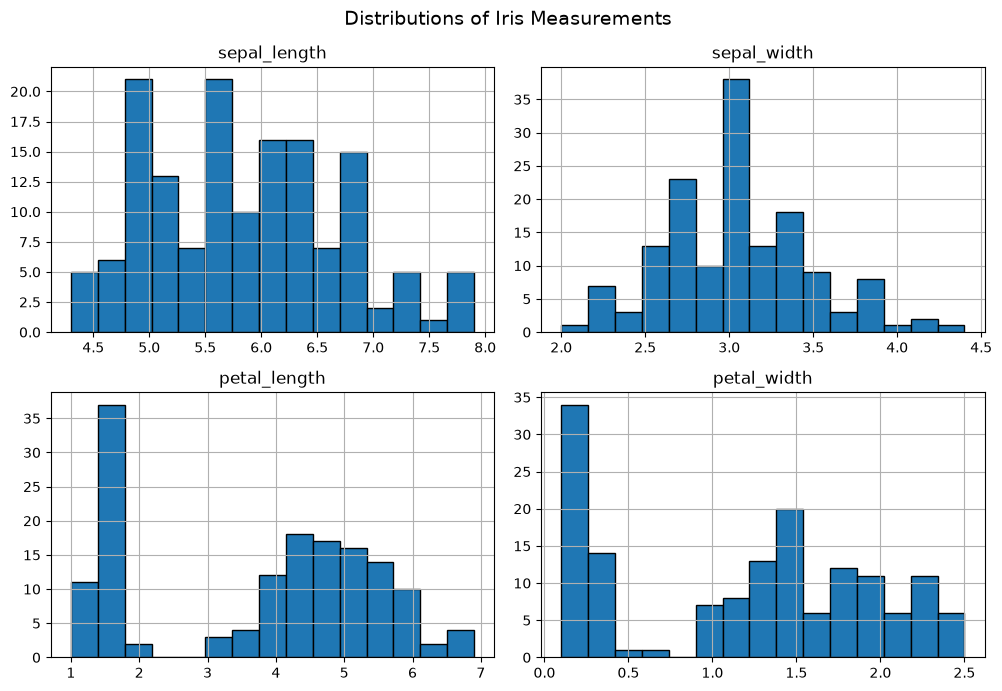

In [32]:
import matplotlib.pyplot as plt

df[numeric_columns].hist(
    bins=15,
    figsize=(10, 7),
    edgecolor="black"
)

plt.suptitle("Distributions of Iris Measurements", fontsize=14)
plt.tight_layout()
plt.show()

### Distribution Observations

- Sepal length and sepal width are relatively concentrated compared with the petal measurements.
- Petal length and petal width show more distinct groupings, suggesting differences between Iris species.
- These patterns indicate that analysing the measurements separately by species may reveal clearer differences.

## Measurements by Species

Boxplots are used to compare the distributions of flower measurements across setosa, versicolor, and virginica.

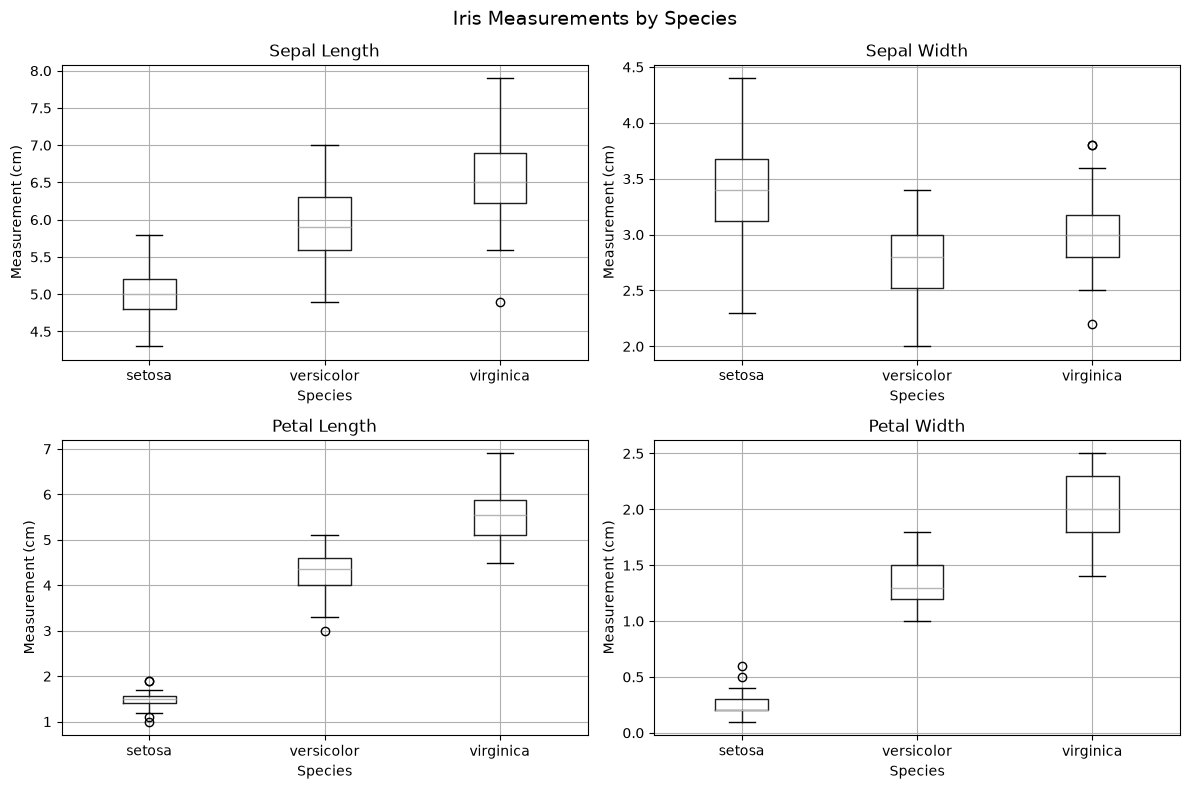

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, column in zip(axes.flatten(), numeric_columns):
    df.boxplot(
        column=column,
        by="species",
        ax=ax
    )
    
    ax.set_title(column.replace("_", " ").title())
    ax.set_xlabel("Species")
    ax.set_ylabel("Measurement (cm)")

plt.suptitle("Iris Measurements by Species", fontsize=14)
plt.tight_layout()
plt.show()

## Correlation Analysis

A correlation matrix is used to examine the relationships between the numerical variables in the Iris dataset.

In [34]:
correlation_matrix = df[numeric_columns].corr()

correlation_matrix.round(3)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.109,0.872,0.818
sepal_width,-0.109,1.000,-0.421,-0.357
petal_length,0.872,-0.421,1.000,0.963
petal_width,0.818,-0.357,0.963,1.000


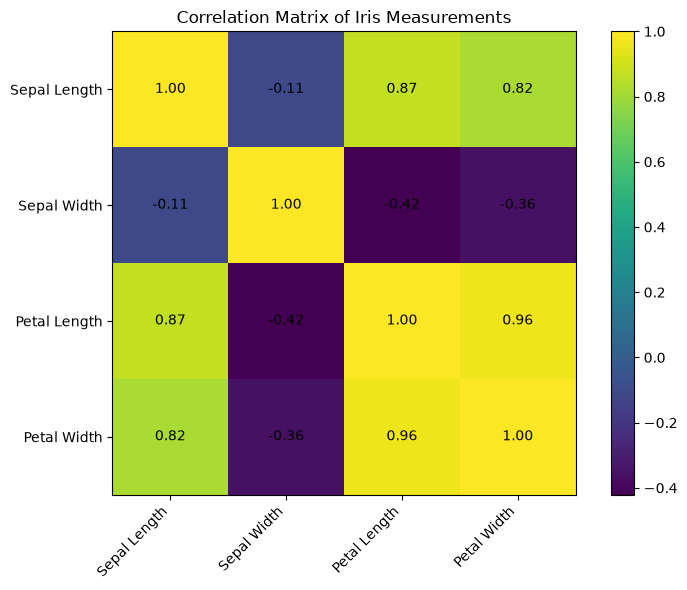

In [35]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(correlation_matrix)

ax.set_xticks(range(len(numeric_columns)))
ax.set_yticks(range(len(numeric_columns)))

ax.set_xticklabels(
    [col.replace("_", " ").title() for col in numeric_columns],
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    [col.replace("_", " ").title() for col in numeric_columns]
)

for i in range(len(numeric_columns)):
    for j in range(len(numeric_columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Correlation Matrix of Iris Measurements")

fig.colorbar(im)
plt.tight_layout()
plt.show()

### Correlation Observations

- Petal length and petal width have a very strong positive correlation, indicating that flowers with longer petals generally also have wider petals.
- Sepal length is strongly positively correlated with both petal length and petal width.
- Sepal width shows a moderate negative relationship with the petal measurements.
- The strong relationships among the petal variables suggest that they may be useful for distinguishing between Iris species.

## Petal Length vs Petal Width

A scatter plot is used to examine the relationship between petal length and petal width and to observe how the three Iris species differ.

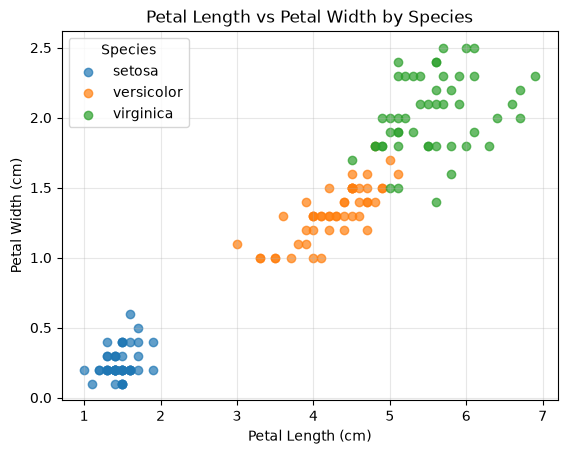

In [38]:
import matplotlib.pyplot as plt

species_list = df["species"].unique()

for species in species_list:
    species_data = df[df["species"] == species]

    plt.scatter(
        species_data["petal_length"],
        species_data["petal_width"],
        label=species,
        alpha=0.7
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width by Species")
plt.legend(title="Species")
plt.grid(alpha=0.3)
plt.show()

### Scatter Plot Observations

- Petal length and petal width show a strong positive relationship.
- Setosa forms a clearly separated cluster with much smaller petal measurements.
- Versicolor generally has medium-sized petals, while virginica has the largest petal measurements.
- There is some overlap between versicolor and virginica, but the two species are still reasonably distinguishable.
- This supports the earlier correlation result showing that petal length and petal width are strongly related.

# Iris Dataset Exploration

**Project:** Statistics Superstars – Data Detective: Exploring Real-World Distributions

**Dataset:** Iris Flower Dataset

This notebook explores the structure, variables, data quality, and basic characteristics of the Iris dataset before performing statistical analysis.